ПРАКТИЧЕСКАЯ РАБОТА №3
Метод простой итерации
Уравнение: 10*cos(x) - 0.1*x^2 = 0
--------------------------------------------------
Начальное x0 = 1.5
Точность: 0.001

Итерация 1: x0 = 1.500000 -> x1 = 1.548294, |x1-x0| = 0.048294
Итерация 2: x1 = 1.548294 -> x2 = 1.546822, |x2-x1| = 0.001473
Итерация 3: x2 = 1.546822 -> x3 = 1.546867, |x3-x2| = 0.000046

Точность достигнута на 3-й итерации!
Корень уравнения: x = 1.546867
Округленно: x = 1.547


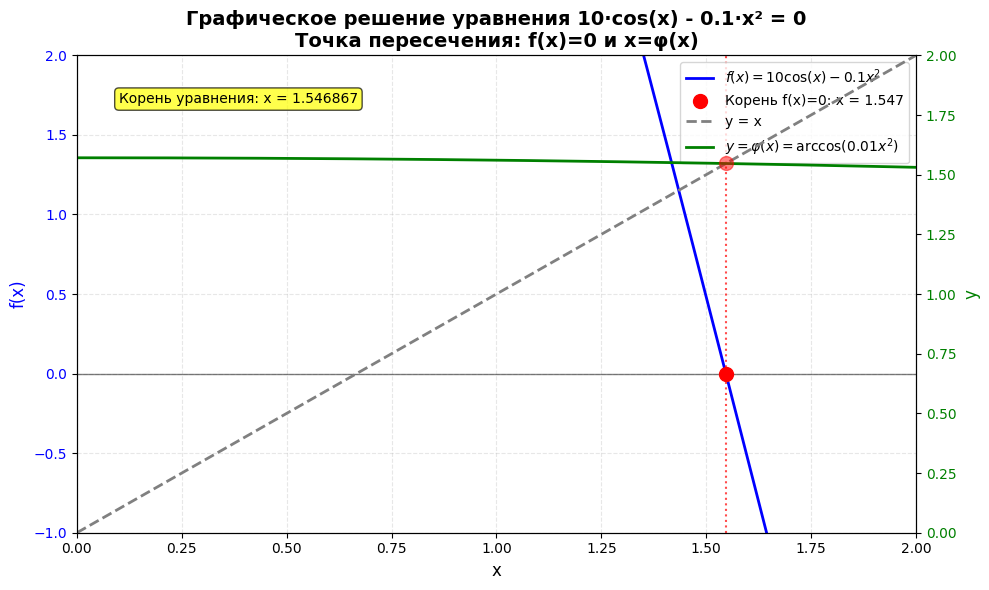

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

print("ПРАКТИЧЕСКАЯ РАБОТА №3")
print("Метод простой итерации")
print("Уравнение: 10*cos(x) - 0.1*x^2 = 0")
print("-" * 50)

# Функция для итерационного процесса x = φ(x)
def phi(x):
    return math.acos(0.01 * x * x)

# Начальное приближение
x = 1.5
eps = 0.001
max_iter = 20

print(f"Начальное x0 = {x}")
print(f"Точность: {eps}")
print()

for i in range(max_iter):
    x_old = x
    x = phi(x_old)
    
    print(f"Итерация {i+1}: x{i} = {x_old:.6f} -> x{i+1} = {x:.6f}, |x{i+1}-x{i}| = {abs(x - x_old):.6f}")
    
    if abs(x - x_old) < eps:
        print(f"\nТочность достигнута на {i+1}-й итерации!")
        print(f"Корень уравнения: x = {x:.6f}")
        print(f"Округленно: x = {x:.3f}")
        break
else:
    print(f"\nДостигнуто максимальное число итераций ({max_iter})")

# Подготовка данных для графиков
x_vals = np.linspace(0, 2, 400)
y_func = 10 * np.cos(x_vals) - 0.1 * x_vals**2  # f(x)
y_phi = np.arccos(0.01 * x_vals**2)  # φ(x)

# Создаем один график с двумя разными представлениями
fig, ax1 = plt.subplots(figsize=(10, 6))

# Первая ось: f(x) = 10*cos(x) - 0.1*x^2
ax1.plot(x_vals, y_func, label=r'$f(x) = 10\cos(x) - 0.1x^2$', color='blue', linewidth=2)
ax1.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3, linestyle='--')

# Вторая ось: y = x и y = φ(x) для метода итераций
ax2 = ax1.twinx()  # Создаем вторую ось Y
ax2.plot(x_vals, x_vals, label='y = x', color='gray', linestyle='--', linewidth=2)
ax2.plot(x_vals, y_phi, label=r'$y = \varphi(x) = \arccos(0.01x^2)$', color='green', linewidth=2)
ax2.set_ylabel('y', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Отмечаем точки пересечения
ax1.plot(x, 0, 'ro', markersize=10, label=f'Корень f(x)=0: x = {x:.3f}')
ax2.plot(x, x, 'ro', markersize=10, alpha=0.5)  # Точка на втором графике

# Добавляем вертикальную линию в точке корня
ax1.axvline(x=x, color='red', linestyle=':', alpha=0.7, linewidth=1.5)

# Объединяем легенды
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# Заголовок
plt.title('Графическое решение уравнения 10·cos(x) - 0.1·x² = 0\n' + 
          'Точка пересечения: f(x)=0 и x=φ(x)', 
          fontsize=14, fontweight='bold')

# Добавляем текстовую информацию на график
plt.text(0.1, 1.8, f'Корень уравнения: x = {x:.6f}', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
         fontsize=10)

plt.xlim(0, 2)
ax1.set_ylim(-1, 2)
ax2.set_ylim(0, 2)

plt.tight_layout()
plt.show()